In [21]:
import numpy as np
import matplotlib.pyplot as plt

# seed for reproducibility
np.random.seed(42)

## Reminder Fourier

* Modulation:
$$
\mathcal F\{ x(t) \cos(2\pi f_ct) \} = \frac 1 2 \left[ X(f-f_c) + X(f+f_c) \right]
$$

## Carrier Frequency and Modulation

A carrier is a pure sinusoidal wave at some high frequency $f_c$ used to carry lower-frequency information (the baseband). For example, a microphone signal typically occupies 0-5kHz (the human voice range), but a radio station needs to broadcast it around 100 MHz.

So, we multiply that audio with a sinusoid,

$$s(t) = m(t) \cdot \cos(2\pi f_ct)$$

where $m(t)$ is your audio (the baseband signal) and $f_c = 100 \text{MHz}$.

## Why the SDR outputs the complex envelope

TL;DR: mathematical trick that makes things simpler and cheaper.

If you try to directly digitize an RD carrier (e.g. 100 MHz), you'd need a sampling rate > 200MHz (Nyquist frequency). That's costly and power-hungry.

Instead, the SDR shifts the narrow band you care about (e.g. 100 +- 1 MHz) down to near zero Hz before digitizing.

This is done by mixing the incoming signal with two sinusoids:

$$
\cos(2\pi f_c t) \text{ and } \sin(2\pi f_c t)
$$

That yields two low-frequency signals:

$$
I(t) = s(t) \cos(2\pi f_c t),
\quad
Q(t) = s(t) \sin(2\pi f_c t)
$$

These contain all information of the original band, but now near 0 Hz. This baseband representation is called the complex baseband. 

In [13]:
fs = 10e3  # sampling rate (10MHz)
fc = 2000  # carrier frequency (2kHz)
B = 200  # bandwidth of baseband message
duration = 0.1

t = np.arange(0, duration, 1/fs)

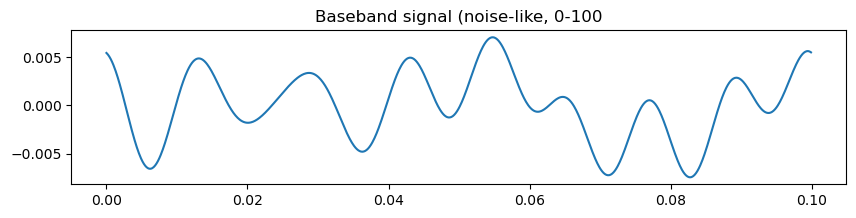

In [37]:
# Create baseband signal (band-limited noise)
N = len(t)
# get the corresponding frequencies in Fourier domain
f = np.fft.fftfreq(N, 1/fs)
X = np.zeros(N, dtype=complex)
band = np.abs(f) < B/2
X[band] = np.random.randn(band.sum()) + 1j * np.random.randn(band.sum())

x_baseband = np.fft.ifft(X).real

plt.figure(figsize=(10, 2))
plt.plot(t[:1000], x_baseband[:1000])
plt.title(f'Baseband signal (noise-like, 0-{B/2:.0f}');

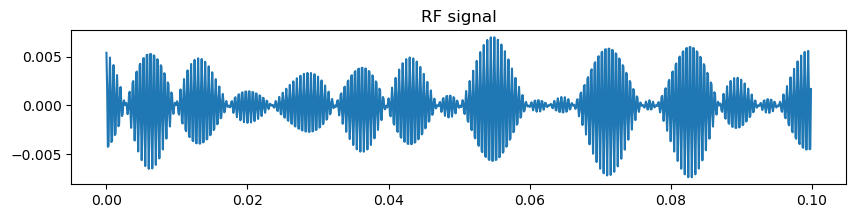

In [38]:
# Modulate onto carrier
x_rf = x_baseband * np.cos(2 * np.pi * fc * t)

plt.figure(figsize=(10, 2))
plt.plot(t[:1000], x_rf[:1000])
plt.title('RF signal');

In [30]:
def plot_spectrum(x, title, fs=fs):
    N = len(x)
    S = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

    plt.figure(figsize=(8, 3))
    plt.plot(f, 20*np.log10(np.abs(S) / np.max(np.abs(S))))
    plt.title(title)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    plt.grid(True)

/tmp/ipykernel_483127/1213757544.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.plot(f, 20*np.log10(np.abs(S) / np.max(np.abs(S))))


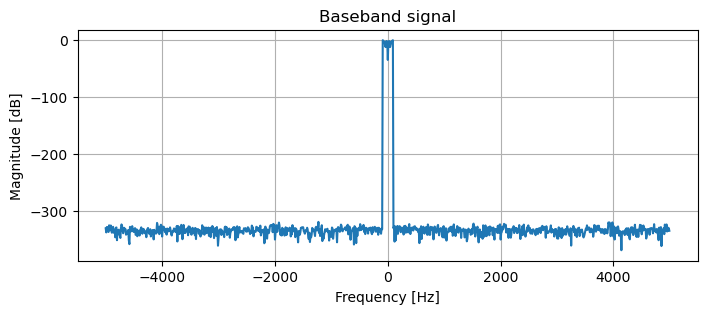

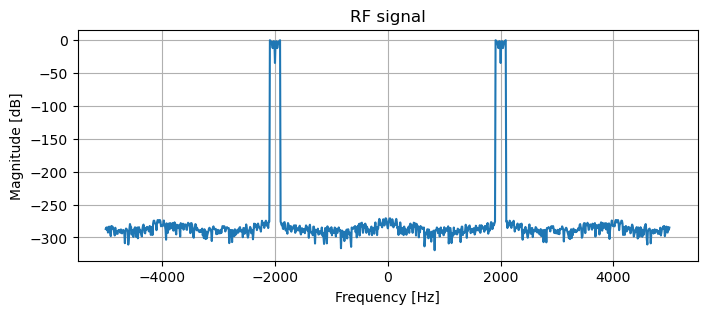

In [39]:
plot_spectrum(x_baseband, 'Baseband signal')
plot_spectrum(x_rf, 'RF signal');

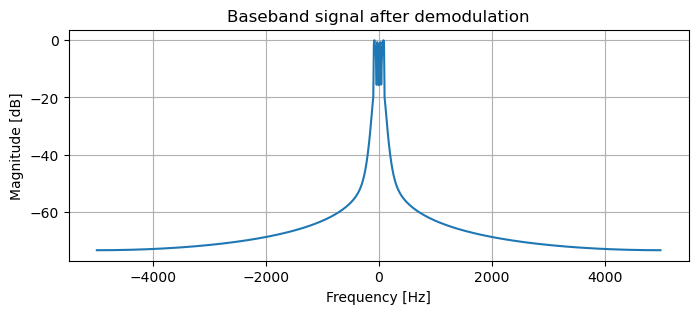

In [42]:
# Mix down (demodulate) using cosine and sine
I = x_rf * np.cos(2 * np.pi * fc * t)
Q = x_rf * np.sin(2 * np.pi * fc * t)

x_complex = I + 1j * Q

# apply low-pass filter (keep onlz the baseband)
from scipy.signal import butter, lfilter
b, a = butter(4, (B/2)/(fs/2))
I_lp = lfilter(b, a, I)
Q_lp = lfilter(b, a, Q)

x_bb = I_lp + 1j * Q_lp

plot_spectrum(x_bb, 'Baseband signal after demodulation');

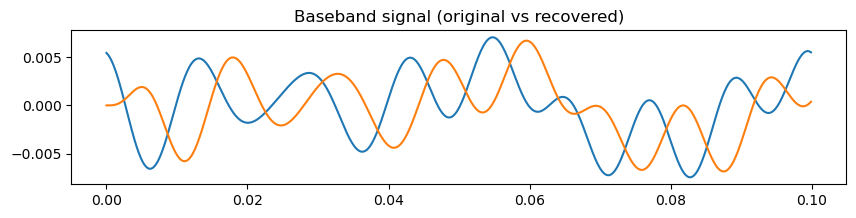

In [48]:
# Compare original and recovered baseband
plt.figure(figsize=(10, 2))
plt.plot(t[:1000], x_baseband[:1000], label='Original baseband')
plt.plot(t[:1000], 2*I_lp[:1000], label='Recovered (I)')
plt.title('Baseband signal (original vs recovered)');

Same signal but out of phase, because the butter + lfilter introduces phase lag, also we took `ifft(...).real` which kills the imaginary part. 